In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

# Create data for all metrics
emotions = ['Anger', 'Calm', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

# Yadav et al. data
yadav_data = {
    'Precision': [87.00, 76.00, 90.00, 81.00, 83.00, 56.00, 83.00, 81.00],
    'Recall': [79.00, 84.00, 90.00, 83.00, 76.00, 60.00, 76.00, 83.00],
    'F1-Score': [83.00, 80.00, 90.00, 82.00, 79.00, 58.00, 79.00, 84.00]
}

# Proposed model data
proposed_data = {
    'Precision': [97.00, 75.00, 91.00, 83.00, 69.00, 83.00, 76.00, 93.00],
    'Recall': [83.00, 93.00, 97.00, 75.00, 79.00, 50.00, 79.00, 87.00],
    'F1-Score': [90.00, 83.00, 94.00, 79.00, 74.00, 62.00, 78.00, 90.00]
}

# Create DataFrames
df_yadav = pd.DataFrame(yadav_data, index=emotions)
df_proposed = pd.DataFrame(proposed_data, index=emotions)

df_yadav['Model'] = 'Yadav et al.'
df_proposed['Model'] = 'Proposed Model'
df_all = pd.concat([df_yadav, df_proposed])


In [26]:
print(df_all)

           Precision  Recall  F1-Score           Model
Anger           87.0    79.0      83.0    Yadav et al.
Calm            76.0    84.0      80.0    Yadav et al.
Disgust         90.0    90.0      90.0    Yadav et al.
Fear            81.0    83.0      82.0    Yadav et al.
Happiness       83.0    76.0      79.0    Yadav et al.
Neutral         56.0    60.0      58.0    Yadav et al.
Sadness         83.0    76.0      79.0    Yadav et al.
Surprise        81.0    83.0      84.0    Yadav et al.
Anger           97.0    83.0      90.0  Proposed Model
Calm            75.0    93.0      83.0  Proposed Model
Disgust         91.0    97.0      94.0  Proposed Model
Fear            83.0    75.0      79.0  Proposed Model
Happiness       69.0    79.0      74.0  Proposed Model
Neutral         83.0    50.0      62.0  Proposed Model
Sadness         76.0    79.0      78.0  Proposed Model
Surprise        93.0    87.0      90.0  Proposed Model


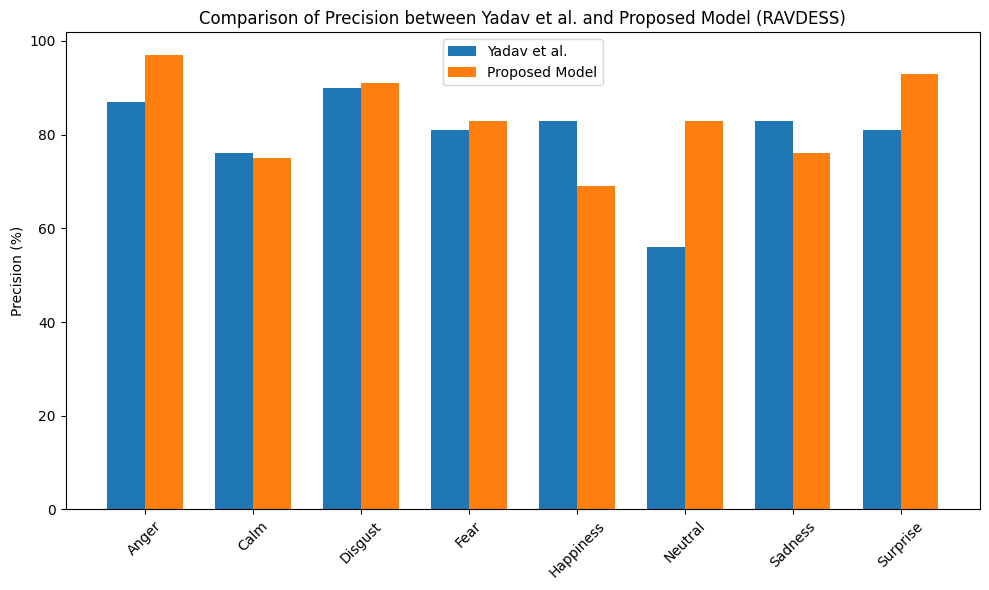

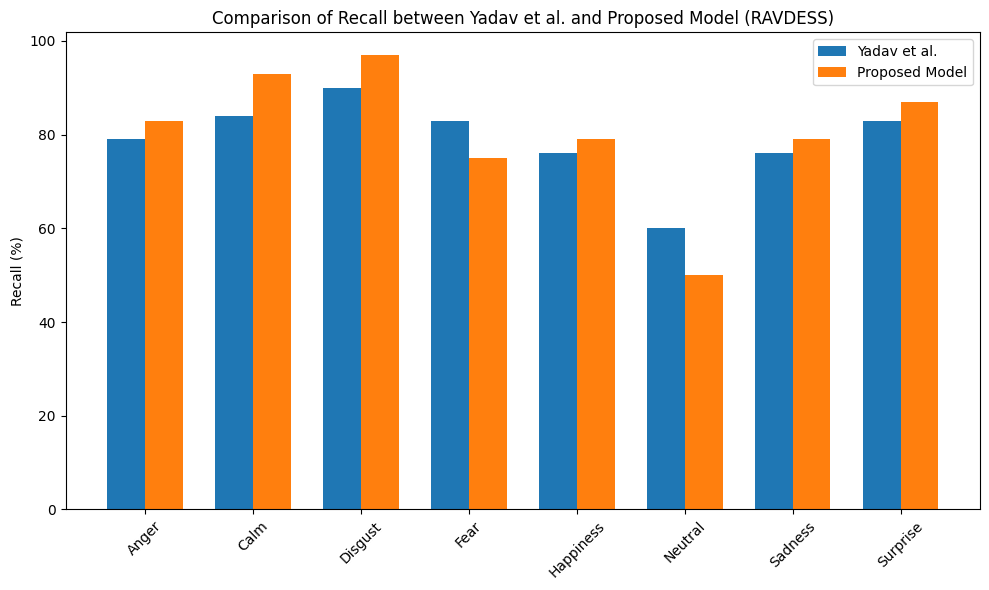

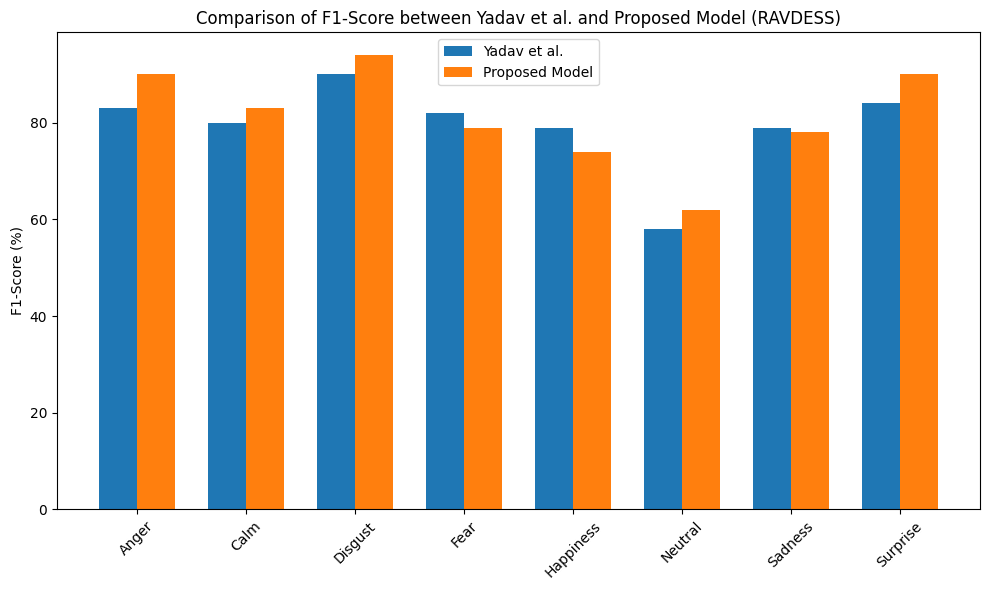

In [27]:

# --- Visualization 1: Grouped Bar Charts ---
metrics = ['Precision', 'Recall', 'F1-Score']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    bar_width = 0.35
    x = np.arange(len(emotions))
    plt.bar(x - bar_width/2, df_yadav[metric], width=bar_width, label='Yadav et al.')
    plt.bar(x + bar_width/2, df_proposed[metric], width=bar_width, label='Proposed Model')
    plt.xticks(x, emotions, rotation=45)
    plt.ylabel(f'{metric} (%)')
    plt.title(f'Comparison of {metric} between Yadav et al. and Proposed Model (RAVDESS)')
    plt.legend()
    plt.tight_layout()
    plt.show()



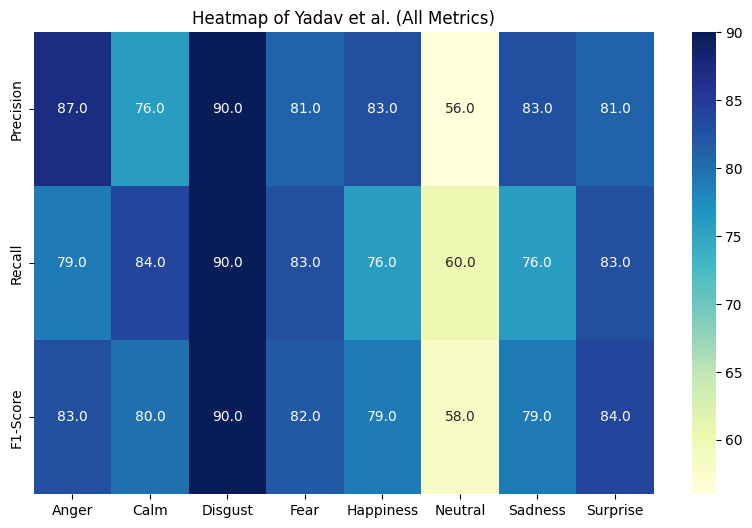

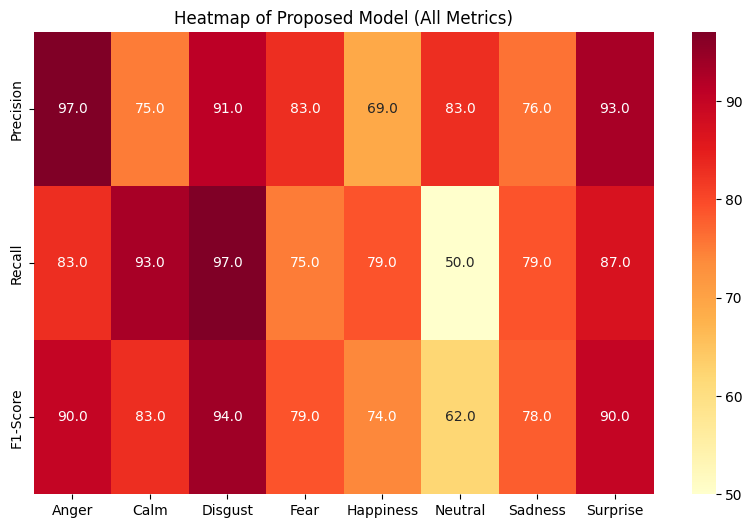

In [28]:
# --- Visualization 2: Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(df_yadav[metrics].T, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Heatmap of Yadav et al. (All Metrics)')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df_proposed[metrics].T, annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('Heatmap of Proposed Model (All Metrics)')
plt.show()


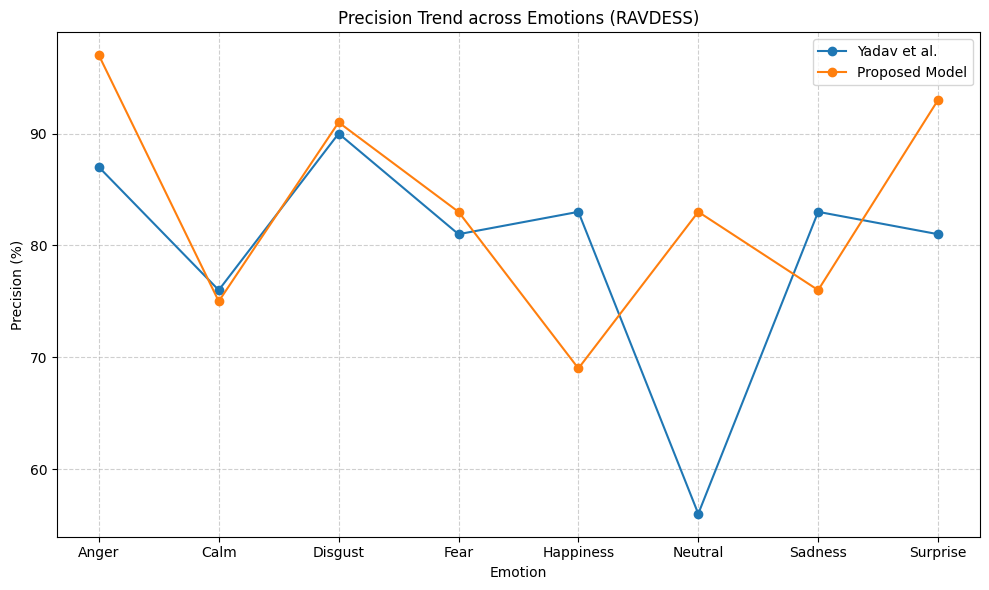

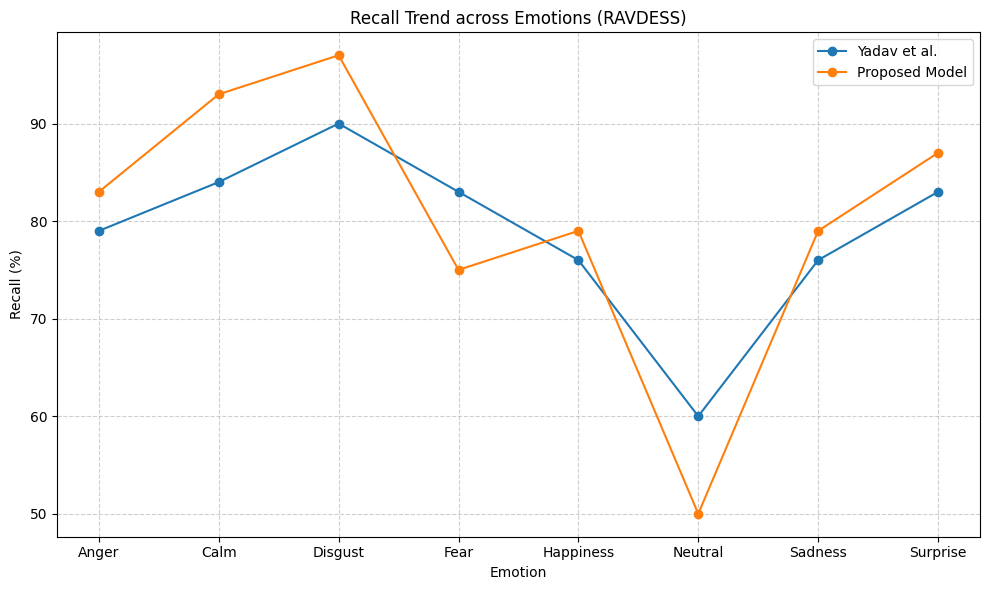

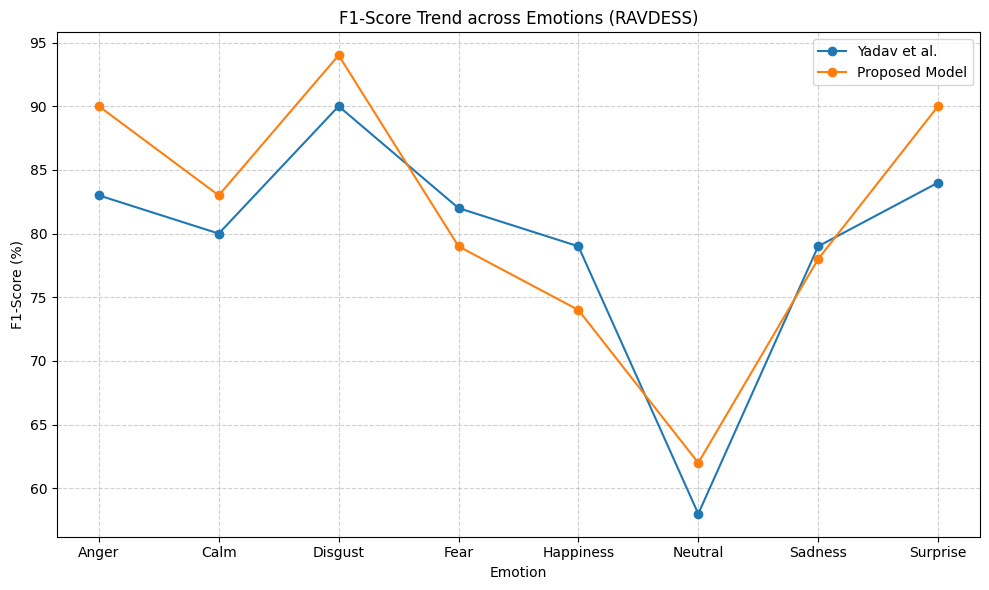

In [29]:

# --- Visualization 3: Line Chart ---
for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.plot(emotions, df_yadav[metric], marker='o', label='Yadav et al.')
    plt.plot(emotions, df_proposed[metric], marker='o', label='Proposed Model')
    plt.title(f'{metric} Trend across Emotions (RAVDESS)')
    plt.xlabel('Emotion')
    plt.ylabel(f'{metric} (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


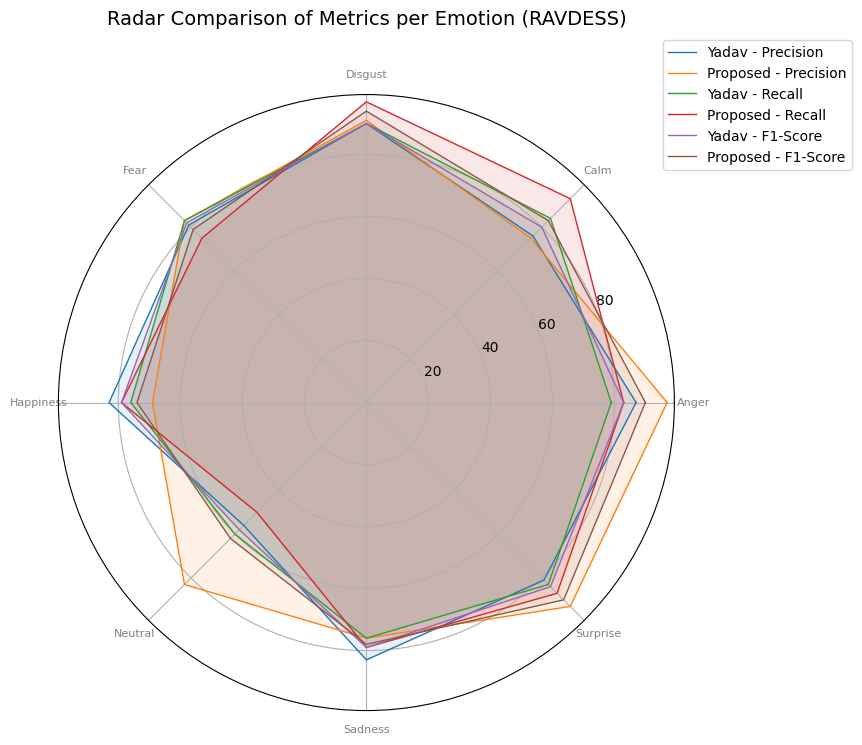

In [30]:

# --- Visualization 4: Radar Chart ---
def make_radar_chart(df1, df2, title):
    categories = list(df1.index)
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], categories, color='grey', size=8)

    for metric in metrics:
        values1 = df1[metric].tolist()
        values1 += values1[:1]
        values2 = df2[metric].tolist()
        values2 += values2[:1]
        ax.plot(angles, values1, linewidth=1, linestyle='solid', label=f'Yadav - {metric}')
        ax.fill(angles, values1, alpha=0.1)
        ax.plot(angles, values2, linewidth=1, linestyle='solid', label=f'Proposed - {metric}')
        ax.fill(angles, values2, alpha=0.1)

    plt.title(title, size=14, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

make_radar_chart(df_yadav, df_proposed, 'Radar Comparison of Metrics per Emotion (RAVDESS)')

In [31]:
import pandas as pd

# Create data for all metrics
emotions = ['Anger', 'Calm', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

# Yadav et al. data
yadav_data = {
    'Precision': [87.00, 76.00, 90.00, 81.00, 83.00, 56.00, 83.00, 81.00],
    'Recall': [79.00, 84.00, 90.00, 83.00, 76.00, 60.00, 76.00, 83.00],
    'F1-Score': [83.00, 80.00, 90.00, 82.00, 79.00, 58.00, 79.00, 84.00]
}

# Proposed model data
proposed_data = {
    'Precision': [97.00, 75.00, 91.00, 83.00, 69.00, 83.00, 76.00, 93.00],
    'Recall': [83.00, 93.00, 97.00, 75.00, 79.00, 50.00, 79.00, 87.00],
    'F1-Score': [90.00, 83.00, 94.00, 79.00, 74.00, 62.00, 78.00, 90.00]
}

# Create the comparison table with multi-line headers
data = {
    'Emotion': emotions,
    'Prec_Yadav': yadav_data['Precision'],
    'Prec_Prop': proposed_data['Precision'],
    'Rec_Yadav': yadav_data['Recall'],
    'Rec_Prop': proposed_data['Recall'],
    'F1_Yadav': yadav_data['F1-Score'],
    'F1_Prop': proposed_data['F1-Score']
}

df = pd.DataFrame(data)

# Print header
print("\n" + "="*120)
print("EMOTION CLASSIFICATION PERFORMANCE COMPARISON")
print("="*120)
print(f"{'':20}  {'Precision':20} {'Recall':20} {'F1-Score':20}")
print(f"{'Emotion':11} {'Yadav':>9} {'Proposed':>10} {'Yadav':>9} {'Proposed':>10} {'Yadav':>9} {'Proposed':>10}")
print("-"*120)

# Print data rows
for i, row in df.iterrows():
    print(f"{row['Emotion']:11} {row['Prec_Yadav']:>9.2f} {row['Prec_Prop']:>10.2f} {row['Rec_Yadav']:>9.2f} {row['Rec_Prop']:>10.2f} {row['F1_Yadav']:>9.2f} {row['F1_Prop']:>10.2f}")

print("="*120)


EMOTION CLASSIFICATION PERFORMANCE COMPARISON
                      Precision            Recall               F1-Score            
Emotion         Yadav   Proposed     Yadav   Proposed     Yadav   Proposed
------------------------------------------------------------------------------------------------------------------------
Anger           87.00      97.00     79.00      83.00     83.00      90.00
Calm            76.00      75.00     84.00      93.00     80.00      83.00
Disgust         90.00      91.00     90.00      97.00     90.00      94.00
Fear            81.00      83.00     83.00      75.00     82.00      79.00
Happiness       83.00      69.00     76.00      79.00     79.00      74.00
Neutral         56.00      83.00     60.00      50.00     58.00      62.00
Sadness         83.00      76.00     76.00      79.00     79.00      78.00
Surprise        81.00      93.00     83.00      87.00     84.00      90.00


In [32]:
from scipy import stats
import numpy as np
import pandas as pd

metrics = ['Precision', 'Recall', 'F1-Score']

alpha = 0.05  # Significance level

# Store results
results = []

print("\n" + "="*100)
print("SHAPIRO-WILK NORMALITY TEST FOR ALL METRICS")
print("="*100)

for metric in metrics:
    print(f"\n{'─'*100}")
    print(f"METRIC: {metric}")
    print(f"{'─'*100}")
    
    yadav = np.array(yadav_data[metric])
    proposed = np.array(proposed_data[metric])
    
    # Perform Shapiro-Wilk test
    stat_y, p_y = stats.shapiro(yadav)
    stat_p, p_p = stats.shapiro(proposed)
    
    # Determine normality
    yadav_normal = p_y > alpha
    proposed_normal = p_p > alpha
    both_normal = yadav_normal and proposed_normal
    
    print(f"\nYadav et al. {metric}:")
    print(f"  Data: {yadav.tolist()}")
    print(f"  Test Statistic: {stat_y:.6f}")
    print(f"  P-value: {p_y:.6f}")
    print(f"  Status: {'✓ NORMAL' if yadav_normal else '✗ NOT NORMAL'} (α = {alpha})")
    
    print(f"\nProposed Model {metric}:")
    print(f"  Data: {proposed.tolist()}")
    print(f"  Test Statistic: {stat_p:.6f}")
    print(f"  P-value: {p_p:.6f}")
    print(f"  Status: {'✓ NORMAL' if proposed_normal else '✗ NOT NORMAL'} (α = {alpha})")
    
    print(f"\nConclusion:")
    if both_normal:
        recommendation = "Paired T-Test"
        print(f"  ✓ Both distributions are NORMAL")
    else:
        recommendation = "Wilcoxon Signed-Rank Test"
        print(f"  ✗ At least one distribution is NOT NORMAL")
    
    print(f"  → Recommended Test: {recommendation}")
    
    # Store results
    results.append({
        'Metric': metric,
        'Yadav_Statistic': stat_y,
        'Yadav_P-Value': p_y,
        'Yadav_Normal': yadav_normal,
        'Proposed_Statistic': stat_p,
        'Proposed_P-Value': p_p,
        'Proposed_Normal': proposed_normal,
        'Both_Normal': both_normal,
        'Recommended_Test': recommendation
    })

# Create summary table
print(f"\n{'='*100}")
print("SUMMARY TABLE")
print(f"{'='*100}\n")

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Print recommendation summary
print(f"\n{'='*100}")
print("OVERALL RECOMMENDATIONS")
print(f"{'='*100}")

for _, row in df_results.iterrows():
    print(f"\n{row['Metric']}:")
    print(f"  Yadav Status:    {row['Yadav_Normal']} (p = {row['Yadav_P-Value']:.6f})")
    print(f"  Proposed Status: {row['Proposed_Normal']} (p = {row['Proposed_P-Value']:.6f})")
    print(f"  Test to Use:     {row['Recommended_Test']}")

print(f"\n{'='*100}\n")


SHAPIRO-WILK NORMALITY TEST FOR ALL METRICS

────────────────────────────────────────────────────────────────────────────────────────────────────
METRIC: Precision
────────────────────────────────────────────────────────────────────────────────────────────────────

Yadav et al. Precision:
  Data: [87.0, 76.0, 90.0, 81.0, 83.0, 56.0, 83.0, 81.0]
  Test Statistic: 0.790874
  P-value: 0.022841
  Status: ✗ NOT NORMAL (α = 0.05)

Proposed Model Precision:
  Data: [97.0, 75.0, 91.0, 83.0, 69.0, 83.0, 76.0, 93.0]
  Test Statistic: 0.955506
  P-value: 0.766370
  Status: ✓ NORMAL (α = 0.05)

Conclusion:
  ✗ At least one distribution is NOT NORMAL
  → Recommended Test: Wilcoxon Signed-Rank Test

────────────────────────────────────────────────────────────────────────────────────────────────────
METRIC: Recall
────────────────────────────────────────────────────────────────────────────────────────────────────

Yadav et al. Recall:
  Data: [79.0, 84.0, 90.0, 83.0, 76.0, 60.0, 76.0, 83.0]
  Test S

In [35]:
from scipy import stats
import numpy as np
import pandas as pd

# Your model results
emotions = ['Anger', 'Calm', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

# Yadav et al. data (Baseline)
yadav_data = {
    'Precision': [87.00, 76.00, 90.00, 81.00, 83.00, 56.00, 83.00, 81.00],
    'Recall': [79.00, 84.00, 90.00, 83.00, 76.00, 60.00, 76.00, 83.00],
    'F1-Score': [83.00, 80.00, 90.00, 82.00, 79.00, 58.00, 79.00, 84.00]
}

# Proposed model data (Hybrid)
proposed_data = {
    'Precision': [97.00, 75.00, 91.00, 83.00, 69.00, 83.00, 76.00, 93.00],
    'Recall': [83.00, 93.00, 97.00, 75.00, 79.00, 50.00, 79.00, 87.00],
    'F1-Score': [90.00, 83.00, 94.00, 79.00, 74.00, 62.00, 78.00, 90.00]
}

# Test recommendations based on Shapiro-Wilk results
test_recommendations = {
    'Precision': 'Wilcoxon Signed-Rank Test',
    'Recall': 'Paired T-Test',
    'F1-Score': 'Wilcoxon Signed-Rank Test'
}

metrics = ['Precision', 'Recall', 'F1-Score']
alpha = 0.05

# Store results
statistical_results = []

print("\n" + "="*120)
print("STATISTICAL ANALYSIS: PROPOSED MODEL vs YADAV ET AL.")
print("="*120)

for metric in metrics:
    print(f"\n{'─'*120}")
    print(f"METRIC: {metric}")
    print(f"{'─'*120}")
    
    yadav = np.array(yadav_data[metric])
    proposed = np.array(proposed_data[metric])
    differences = proposed - yadav
    
    # Calculate descriptive statistics
    yadav_mean = np.mean(yadav)
    proposed_mean = np.mean(proposed)
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)
    se_diff = std_diff / np.sqrt(len(differences))
    
    print(f"\nYadav et al. {metric}:")
    print(f"  Mean: {yadav_mean:.2f}%")
    print(f"  Std Dev: {np.std(yadav, ddof=1):.2f}%")
    print(f"  Data: {yadav.tolist()}")
    
    print(f"\nProposed Model {metric}:")
    print(f"  Mean: {proposed_mean:.2f}%")
    print(f"  Std Dev: {np.std(proposed, ddof=1):.2f}%")
    print(f"  Data: {proposed.tolist()}")
    
    print(f"\nDifferences (Proposed - Yadav):")
    print(f"  Mean Difference: {mean_diff:.2f}%")
    print(f"  Std Dev of Differences: {std_diff:.2f}%")
    print(f"  Standard Error: {se_diff:.4f}")
    
    # ======================== CHOICE OF TEST ========================
    test_type = test_recommendations[metric]
    
    if test_type == 'Paired T-Test':
        print(f"\n{'TEST APPLIED':^120}")
        print(f"{'Paired T-Test (Both distributions are NORMAL)':^120}")
        print("─"*120)
        
        # Perform paired t-test
        t_statistic, p_value = stats.ttest_rel(proposed, yadav)
        
        # Calculate 95% confidence interval
        df = len(differences) - 1
        t_critical = stats.t.ppf(1 - alpha/2, df)
        ci_lower = mean_diff - t_critical * se_diff
        ci_upper = mean_diff + t_critical * se_diff
        
        # Cohen's d (effect size)
        cohens_d = mean_diff / std_diff if std_diff != 0 else 0
        
        print(f"\nPaired T-Test Results:")
        print(f"  T-Statistic: {t_statistic:.6f}")
        print(f"  P-Value (two-tailed): {p_value:.6f}")
        print(f"  Degrees of Freedom: {df}")
        print(f"  95% Confidence Interval: [{ci_lower:.2f}%, {ci_upper:.2f}%]")
        print(f"  Cohen's d (Effect Size): {cohens_d:.4f}")
        
        # Interpret effect size
        if abs(cohens_d) < 0.2:
            effect_interpretation = "Negligible"
        elif abs(cohens_d) < 0.5:
            effect_interpretation = "Small"
        elif abs(cohens_d) < 0.8:
            effect_interpretation = "Medium"
        else:
            effect_interpretation = "Large"
        
        is_significant = p_value < alpha
        
        print(f"\nConclusion:")
        if is_significant:
            print(f"  ✓ SIGNIFICANT DIFFERENCE (p = {p_value:.6f} < {alpha})")
            if mean_diff > 0:
                print(f"  → Proposed Model performs SIGNIFICANTLY BETTER than Yadav et al.")
            else:
                print(f"  → Yadav et al. performs SIGNIFICANTLY BETTER than Proposed Model")
        else:
            print(f"  ✗ NO SIGNIFICANT DIFFERENCE (p = {p_value:.6f} ≥ {alpha})")
            print(f"  → No statistically significant difference between models")
        
        print(f"  Effect Size: {effect_interpretation} (Cohen's d = {cohens_d:.4f})")
        
        test_statistic = t_statistic
        
    else:  # Wilcoxon Signed-Rank Test
        print(f"\n{'TEST APPLIED':^120}")
        print(f"{'Wilcoxon Signed-Rank Test (At least one distribution is NOT NORMAL)':^120}")
        print("─"*120)
        
        # Perform Wilcoxon signed-rank test
        w_statistic, p_value = stats.wilcoxon(proposed, yadav)
        
        # Calculate effect size for Wilcoxon (r = Z / sqrt(N))
        n = len(differences)
        # Convert W statistic to Z score approximately
        # For large samples: Z = (W - n(n+1)/4) / sqrt(n(n+1)(2n+1)/24)
        mean_w = n * (n + 1) / 4
        std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
        z_score = (w_statistic - mean_w) / std_w
        r_effect = abs(z_score) / np.sqrt(n)
        
        print(f"\nWilcoxon Signed-Rank Test Results:")
        print(f"  W-Statistic: {w_statistic:.6f}")
        print(f"  P-Value (two-tailed): {p_value:.6f}")
        print(f"  Sample Size: {n}")
        print(f"  Z-Score (approximate): {z_score:.6f}")
        print(f"  Effect Size (r): {r_effect:.4f}")
        
        # Interpret effect size for Wilcoxon
        if abs(r_effect) < 0.1:
            effect_interpretation = "Negligible"
        elif abs(r_effect) < 0.3:
            effect_interpretation = "Small"
        elif abs(r_effect) < 0.5:
            effect_interpretation = "Medium"
        else:
            effect_interpretation = "Large"
        
        is_significant = p_value < alpha
        
        print(f"\nConclusion:")
        if is_significant:
            print(f"  ✓ SIGNIFICANT DIFFERENCE (p = {p_value:.6f} < {alpha})")
            if mean_diff > 0:
                print(f"  → Proposed Model performs SIGNIFICANTLY BETTER than Yadav et al.")
            else:
                print(f"  → Yadav et al. performs SIGNIFICANTLY BETTER than Proposed Model")
        else:
            print(f"  ✗ NO SIGNIFICANT DIFFERENCE (p = {p_value:.6f} ≥ {alpha})")
            print(f"  → No statistically significant difference between models")
        
        print(f"  Effect Size: {effect_interpretation} (r = {r_effect:.4f})")
        
        test_statistic = w_statistic
    
    # Store results
    statistical_results.append({
        'Metric': metric,
        'Test_Used': test_type,
        'Yadav_Mean': yadav_mean,
        'Proposed_Mean': proposed_mean,
        'Mean_Difference': mean_diff,
        'Test_Statistic': test_statistic,
        'P_Value': p_value,
        'Significant': is_significant,
        'Effect_Size': effect_interpretation
    })

# ======================== SUMMARY TABLE ========================
print(f"\n{'='*120}")
print("COMPREHENSIVE SUMMARY TABLE")
print(f"{'='*120}\n")

df_results = pd.DataFrame(statistical_results)
print(df_results.to_string(index=False))

# ======================== OVERALL CONCLUSIONS ========================
print(f"\n{'='*120}")
print("OVERALL CONCLUSIONS")
print(f"{'='*120}")

significant_metrics = [row['Metric'] for row in statistical_results if row['Significant']]
if significant_metrics:
    print(f"\n✓ SIGNIFICANT IMPROVEMENTS in: {', '.join(significant_metrics)}")
else:
    print(f"\n✗ NO SIGNIFICANT IMPROVEMENTS found in any metric")

print(f"\nDetailed Performance Comparison:")
for _, row in df_results.iterrows():
    direction = "↑" if row['Mean_Difference'] > 0 else "↓"
    sig_marker = "***" if row['Significant'] else "ns"
    print(f"  {row['Metric']:12s}: {row['Yadav_Mean']:6.2f}% → {row['Proposed_Mean']:6.2f}% ({direction} {abs(row['Mean_Difference']):5.2f}%, p={row['P_Value']:.4f}) [{sig_marker}]")



STATISTICAL ANALYSIS: PROPOSED MODEL vs YADAV ET AL.

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
METRIC: Precision
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Yadav et al. Precision:
  Mean: 79.62%
  Std Dev: 10.42%
  Data: [87.0, 76.0, 90.0, 81.0, 83.0, 56.0, 83.0, 81.0]

Proposed Model Precision:
  Mean: 83.38%
  Std Dev: 9.77%
  Data: [97.0, 75.0, 91.0, 83.0, 69.0, 83.0, 76.0, 93.0]

Differences (Proposed - Yadav):
  Mean Difference: 3.75%
  Std Dev of Differences: 12.60%
  Standard Error: 4.4551

                                                      TEST APPLIED                                                      
                          Wilcoxon Signed-Rank Test (At least one distribution is NOT NORMAL)                           
───────────────────────────────────────────────────────────────────────────────────────────────